## 使用合成数据实现gempy中的地堑构造 

In [1]:
%matplotlib inline
from pyvista import set_plot_theme
set_plot_theme('document')
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Jupyter notebook 的默认后端


# Model 1 - 基础设置 数据的导入与地层的意义

使用3d_gemodeling_and_tepologu的or.csv数据和surf.csv的数据在Gempy2024.2.2版本上重新构建为与深度学习的隐式建模效果进行对比

## 导入必要的库文件

In [2]:
import gempy as gp
import gempy_viewer as gpv


# sphinx_gallery_thumbnail_number = 2

Setting Backend To: AvailableBackends.numpy


Generate the model
Define the path to data



## 定义范围和截面大小

In [3]:
# Create a GeoModel instance
data = gp.data.GeoModel = gp.create_geomodel(
    project_name='Bregenz',
    extent=[-50,520,-420,160,-20,600], #18 km by 41 km
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations= "orientations_r.csv",
        path_to_surface_points="surface_points_r.csv"
    )
)

# 设置剖面网格
gp.set_section_grid(
    grid=data.grid,
    section_dict={
        'section1': ([-130,-420], [640,160], [0,600])
    }
)

Active grids: GridTypes.NONE|SECTIONS|OCTREE


,start,stop,resolution,dist
section1,"[-130, -420]","[640, 160]","[0, 600]",964.002075


In [4]:
# data.orientations_copy

## 定义地层 同时注意定义的地层数量和名称需与录入的数据相符合

In [5]:
gp.map_stack_to_surfaces(
    gempy_model=data,
    mapping_object=  # TODO: This mapping I do not like it too much. We should be able to do it passing the data objects directly
    { 
            "Fault_Series1": ('fault1'), 
            "Fault_Series2": ('fault2'),
            "Strat_Series1": ('ground1','ground2'),
            "Strat_Series2": ('ground3'),

            # "Strat_Series2": ('ground1','ground2'), 
    }
)

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Fault_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=fault1,
	color=#015482,
	is_active=True
)
]
),
StructuralGroup(
	name=Fault_Series2,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=fault2,
	color=#9f0052,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground1,
	color=#ffbe00,
	is_active=True
),
Element(
	name=ground2,
	color=#728f02,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series2,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground3,
	color=#443988,
	is_active=True
)
]
)
],
	fault_relations=
[[False, False, False, False],
 [False, False, False, False],
 [False, False, False, False],
 [False, False, False, False]],

### 定义地层间关系 作用是设置为fault_group的地层对下方的地层关系有约束和限制的作用， 同时输入的数据需要用单引号 进行修饰

In [6]:
gp.set_is_fault(
    frame=data.structural_frame,
    fault_groups=['Fault_Series1','Fault_Series2']
)

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Fault_Series1,
	structural_relation=StackRelationType.FAULT,
	elements=[
Element(
	name=fault1,
	color=#527682,
	is_active=True
)
]
),
StructuralGroup(
	name=Fault_Series2,
	structural_relation=StackRelationType.FAULT,
	elements=[
Element(
	name=fault2,
	color=#527682,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground1,
	color=#ffbe00,
	is_active=True
),
Element(
	name=ground2,
	color=#728f02,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series2,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground3,
	color=#443988,
	is_active=True
)
]
)
],
	fault_relations=
[[False, False,  True,  True],
 [False, False,  True,  True],
 [False, False, False, False],
 [False, False, False, False]],

## 重新进行矩阵的叙述与划分   可选择是否重新进行关系矩阵的划分

## 关系矩阵的行数与列数必须与创建的层总数相同即为n×n

In [7]:
import numpy as np
# Set fault relations manually
gp.set_fault_relation(
    frame=data.structural_frame,
    rel_matrix=np.array([
      [0,1,1,1],
      [0,0,1,1],
      [0,0,0,0],
      [0,0,0,0],
 

    ]
    )
)

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=Fault_Series1,
	structural_relation=StackRelationType.FAULT,
	elements=[
Element(
	name=fault1,
	color=#527682,
	is_active=True
)
]
),
StructuralGroup(
	name=Fault_Series2,
	structural_relation=StackRelationType.FAULT,
	elements=[
Element(
	name=fault2,
	color=#527682,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series1,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground1,
	color=#ffbe00,
	is_active=True
),
Element(
	name=ground2,
	color=#728f02,
	is_active=True
)
]
),
StructuralGroup(
	name=Strat_Series2,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=ground3,
	color=#443988,
	is_active=True
)
]
)
],
	fault_relations=
[[False,  True,  True,  True],
 [False, False,  True,  True],
 [False, False, False, False],
 [False, False, False, False]],

## 模型计算稳定设置

Setting Backend To: AvailableBackends.PYTORCH
Condition number: 50356868.0.
Chunking done: 20 chunks
Condition number: 31831808.0.
Chunking done: 12 chunks
Condition number: 110350176.0.
Chunking done: 36 chunks
Condition number: 36396384.0.
Chunking done: 13 chunks
Chunking done: 21 chunks
Chunking done: 12 chunks
Chunking done: 37 chunks
Chunking done: 14 chunks
Chunking done: 21 chunks
Chunking done: 12 chunks
Chunking done: 37 chunks
Chunking done: 14 chunks
Chunking done: 26 chunks
Chunking done: 15 chunks
Chunking done: 47 chunks
Chunking done: 17 chunks
Chunking done: 26 chunks
Chunking done: 15 chunks
Chunking done: 47 chunks
Chunking done: 17 chunks
Chunking done: 68 chunks
Chunking done: 41 chunks
Chunking done: 125 chunks
Chunking done: 46 chunks


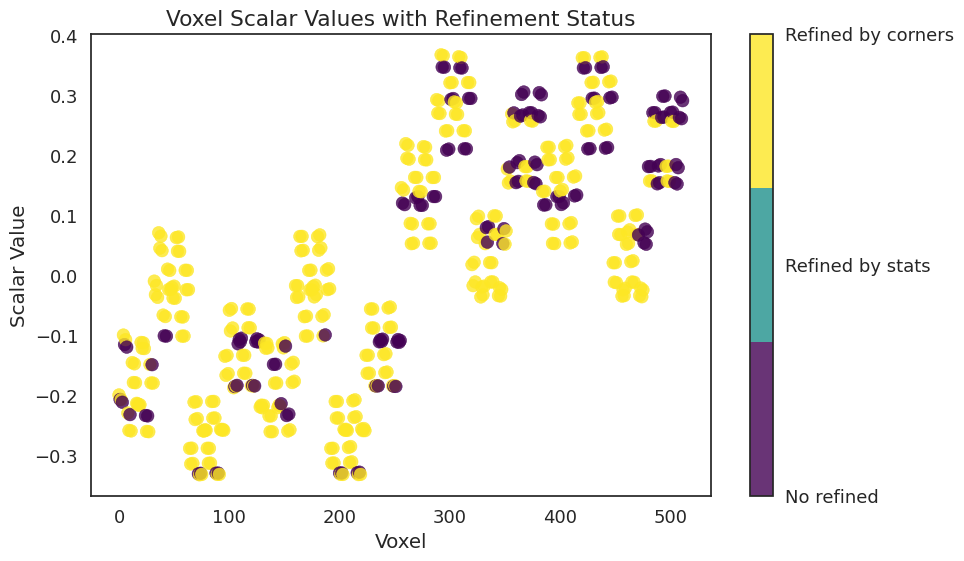

Number of voxels marked by stats: 35 of torch.Size([512]).
 Number of voxels marked by corners : 371
Total voxels: 35
Dense Grid would be 512 voxels


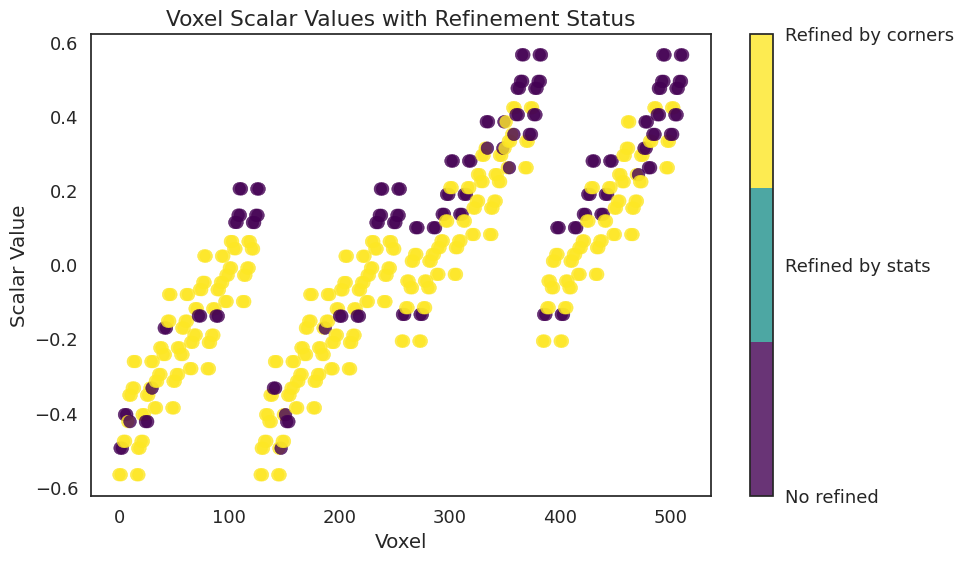

Number of voxels marked by stats: 40 of torch.Size([512]).
 Number of voxels marked by corners : 371
Total voxels: 67
Dense Grid would be 512 voxels


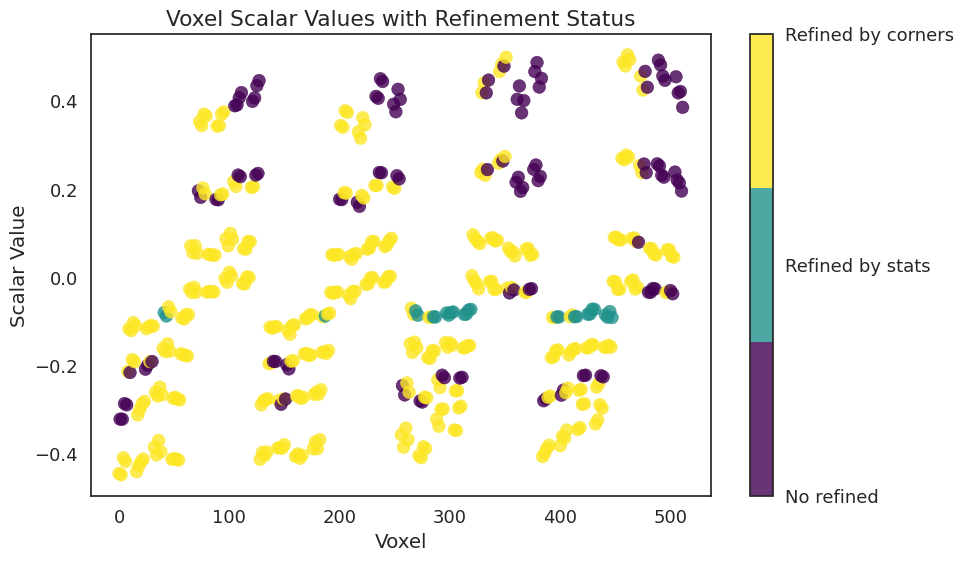

Number of voxels marked by stats: 48 of torch.Size([512]).
 Number of voxels marked by corners : 371
Total voxels: 107
Dense Grid would be 512 voxels


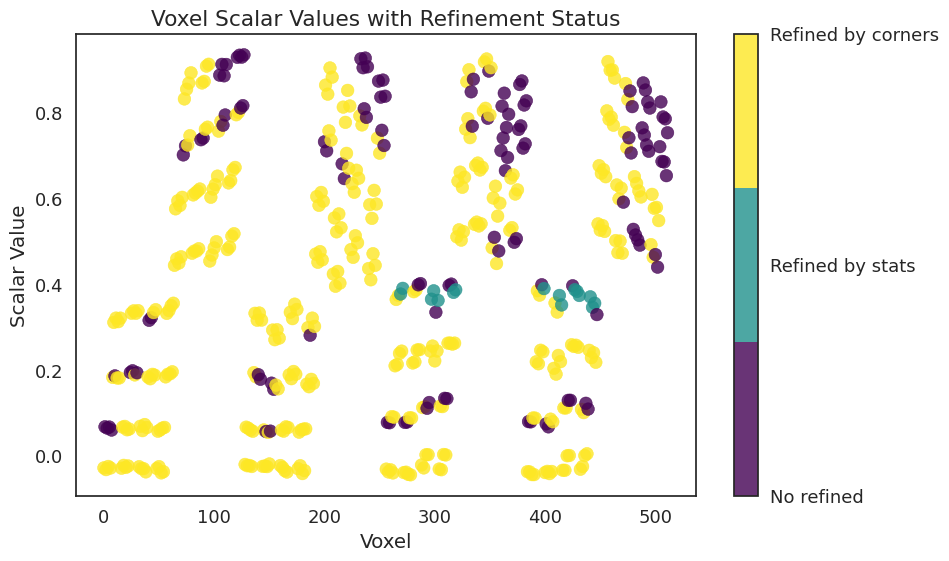

Number of voxels marked by stats: 31 of torch.Size([512]).
 Number of voxels marked by corners : 371
Total voxels: 109
Dense Grid would be 512 voxels
Chunking done: 57 chunks
Chunking done: 34 chunks
Chunking done: 105 chunks
Chunking done: 38 chunks
Chunking done: 321 chunks
Chunking done: 190 chunks
Chunking done: 588 chunks
Chunking done: 214 chunks


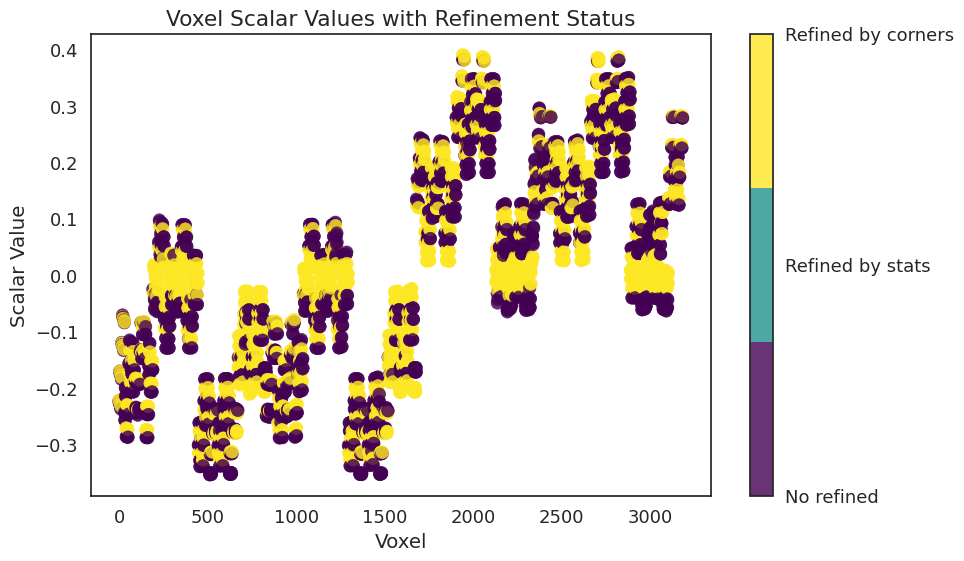

Number of voxels marked by stats: 218 of torch.Size([3184]).
 Number of voxels marked by corners : 1577
Total voxels: 218
Dense Grid would be 4096 voxels


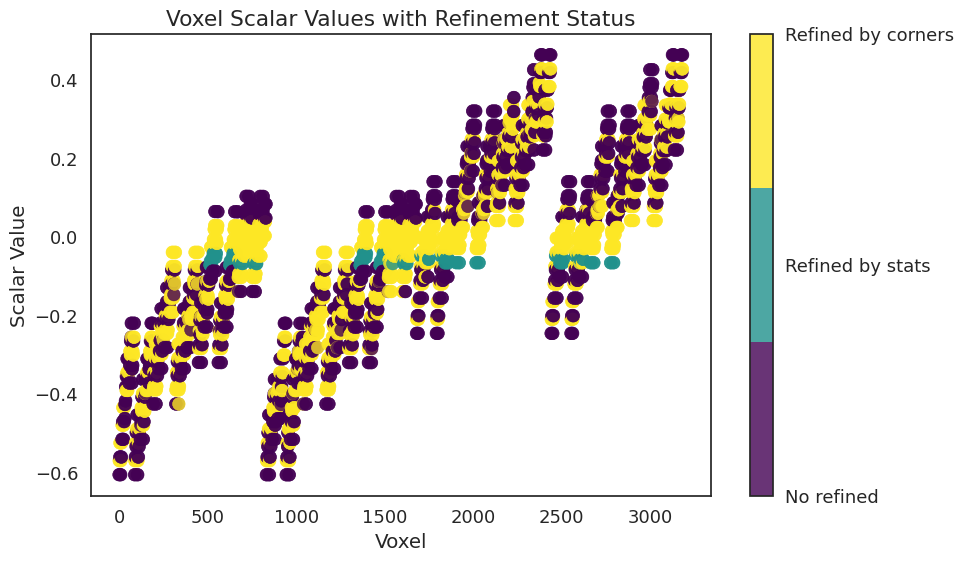

Number of voxels marked by stats: 224 of torch.Size([3184]).
 Number of voxels marked by corners : 1577
Total voxels: 426
Dense Grid would be 4096 voxels


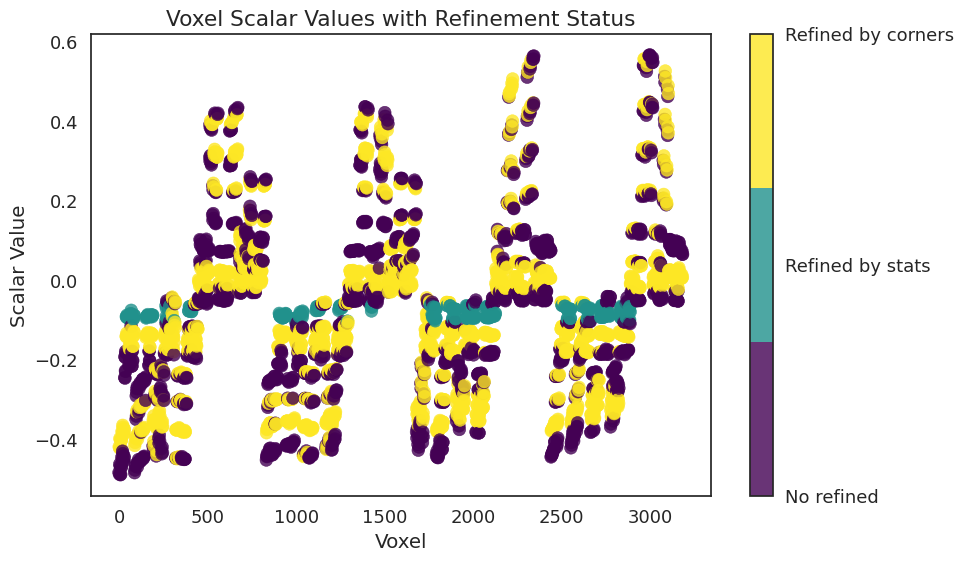

Number of voxels marked by stats: 272 of torch.Size([3184]).
 Number of voxels marked by corners : 1577
Total voxels: 696
Dense Grid would be 4096 voxels


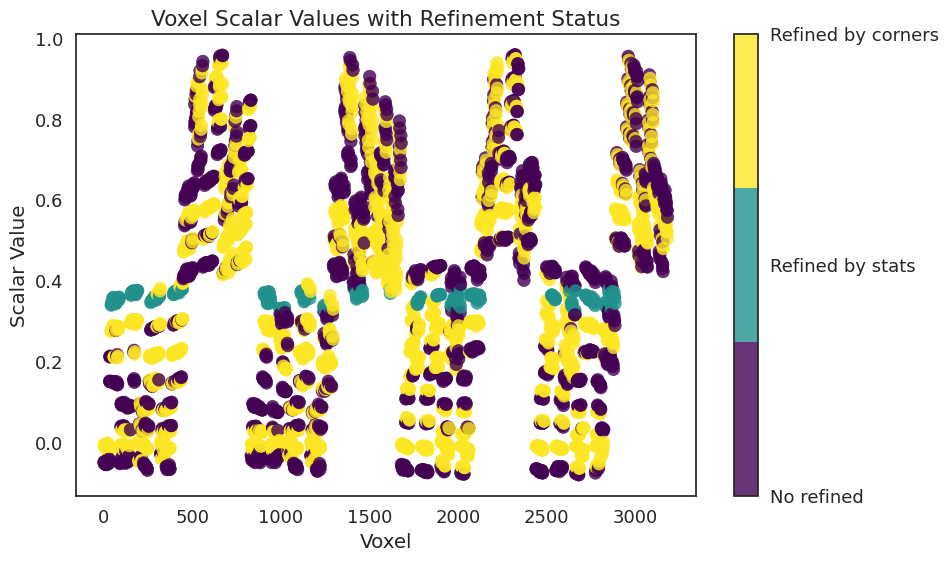

Number of voxels marked by stats: 225 of torch.Size([3184]).
 Number of voxels marked by corners : 1577
Total voxels: 749
Dense Grid would be 4096 voxels
Chunking done: 210 chunks
Condition number: 31831828.0.
Chunking done: 124 chunks
Condition number: 110779336.0.
Chunking done: 385 chunks
Condition number: 36421276.0.
Chunking done: 140 chunks
Chunking done: 1544 chunks
Condition number: 31831808.0.
Chunking done: 912 chunks
Condition number: 110350176.0.
Chunking done: 2830 chunks
Condition number: 36396384.0.
Chunking done: 1027 chunks


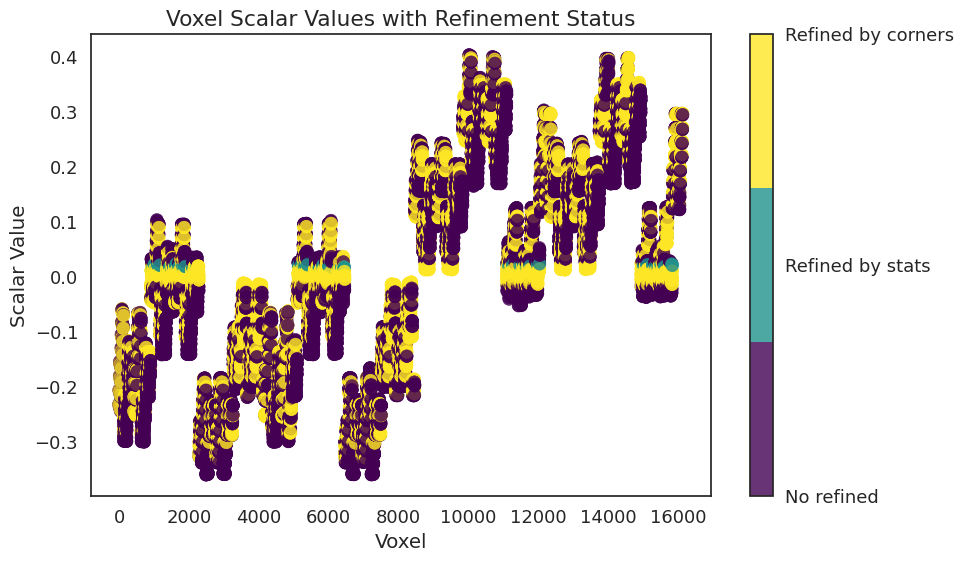

Number of voxels marked by stats: 1637 of torch.Size([16120]).
 Number of voxels marked by corners : 6736
Total voxels: 1637
Dense Grid would be 32768 voxels


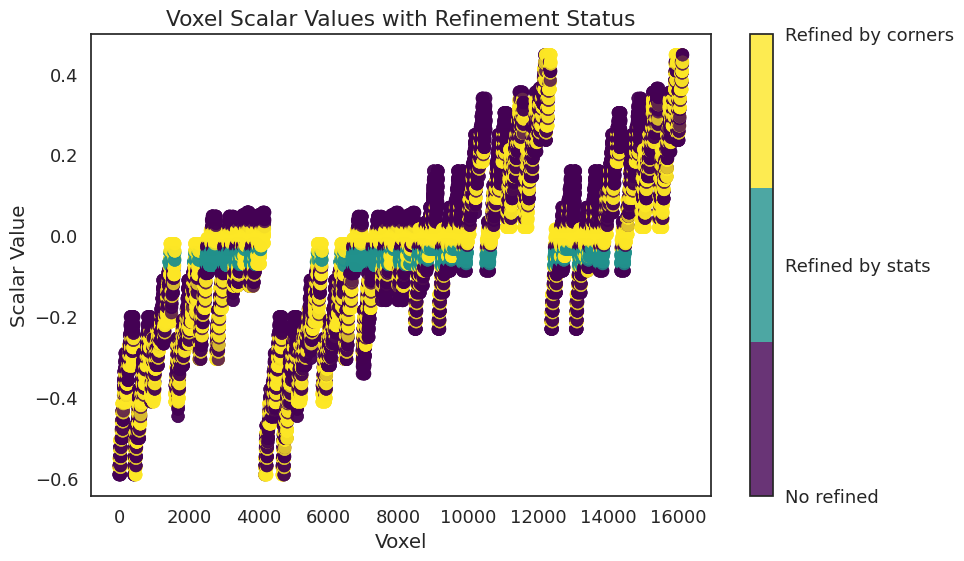

Number of voxels marked by stats: 1870 of torch.Size([16120]).
 Number of voxels marked by corners : 6736
Total voxels: 3411
Dense Grid would be 32768 voxels


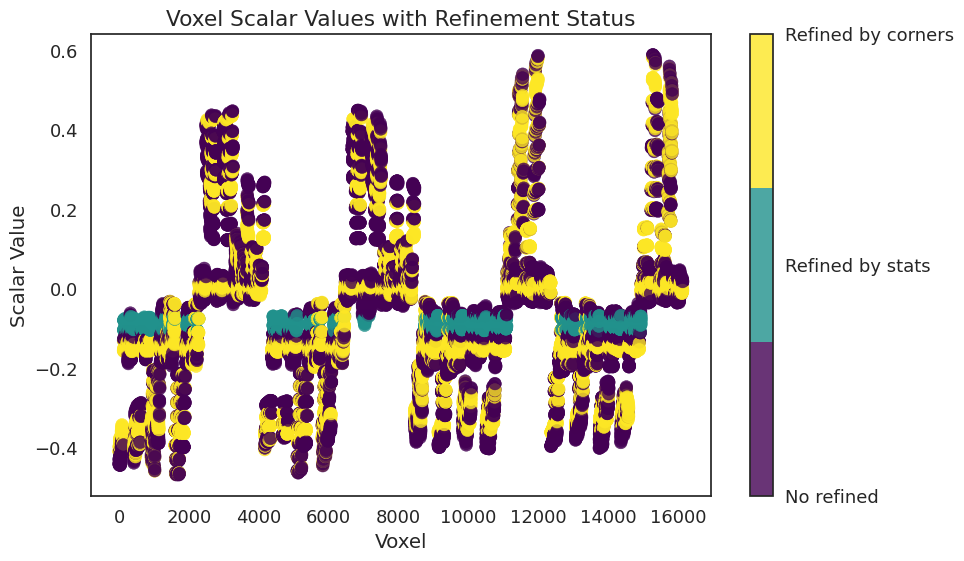

Number of voxels marked by stats: 2021 of torch.Size([16120]).
 Number of voxels marked by corners : 6736
Total voxels: 5297
Dense Grid would be 32768 voxels


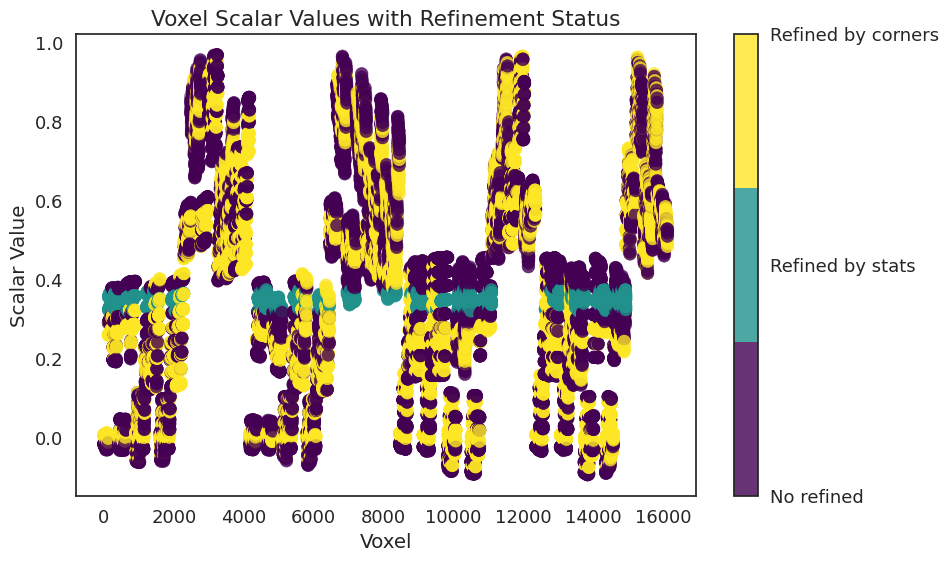

Number of voxels marked by stats: 1489 of torch.Size([16120]).
 Number of voxels marked by corners : 6736
Total voxels: 5595
Dense Grid would be 32768 voxels
Chunking done: 1014 chunks
Condition number: 31831828.0.
Chunking done: 599 chunks
Condition number: 110779336.0.
Chunking done: 1858 chunks
Condition number: 36421276.0.
Chunking done: 674 chunks
Chunking done: 37 chunks
Chunking done: 22 chunks
Condition number: 110779336.0.
Chunking done: 67 chunks
Condition number: 36421276.0.
Chunking done: 25 chunks
Chunking done: 42 chunks
Condition number: 31831808.0.
Chunking done: 25 chunks
Condition number: 110350176.0.
Chunking done: 76 chunks
Condition number: 36396384.0.
Chunking done: 28 chunks
Chunking done: 55 chunks
Chunking done: 33 chunks
Chunking done: 101 chunks
Chunking done: 37 chunks
Chunking done: 36 chunks
Chunking done: 21 chunks
Chunking done: 65 chunks
Chunking done: 24 chunks


In [8]:
# 设定调试与稳定性设置
data.interpolation_options.evaluation_options.verbose = True
data.interpolation_options.kernel_options.compute_condition_number = True

# 调整八叉树划分与 chunk size
data.interpolation_options.evaluation_options.octree_error_threshold = 0.1
data.interpolation_options.evaluation_options.evaluation_chunk_size = 100_000

# 训练时可关闭 mesh 提取
data.interpolation_options.mesh_extraction = True

# 计算模型
_ = gp.compute_model(
    data,
    engine_config=gp.data.GemPyEngineConfig(
        backend=gp.data.AvailableBackends.PYTORCH,
        use_gpu=True,
        dtype="float32"
    )
)

## 服务器保存无GUI情况 三种格式  网格 体素网格 点数据

## 保存的方式 1

In [13]:
import gempy as gp
import pyvista as pv
import numpy as np
from pathlib import Path

def export_surfaces_vtk(geo_model, export_path="./vtk_export"):
    export_path = Path(export_path)
    export_path.mkdir(parents=True, exist_ok=True)

    print("📦 正在导出 VTK 表面...")

    # 获取地质层列表
    surfaces = list(geo_model.structural_frame.element_name_id_map.keys())
    surfaces_poly = {}

    for i, surface in enumerate(surfaces):
        try:
            # 顶点转换为真实坐标系
            vertices = geo_model.input_transform.apply_inverse(geo_model.solutions.raw_arrays.vertices[i])
            faces = geo_model.solutions.raw_arrays.edges[i]

            if faces.shape[1] != 3:
                print(f"⚠️ Surface {surface} 边不是三角形，跳过")
                continue

            # PyVista 要求 faces 每个面前加一个“顶点数量”
            faces = np.insert(faces, 0, 3, axis=1).ravel()

            surf = pv.PolyData(vertices, faces)
            surf['Z'] = vertices[:, 2]  # 附加属性：深度信息

            filename = export_path / f"{surface}.vtp"
            surf.save(filename)
            print(f"✅ {surface} 导出成功: {filename.name}")
        except Exception as e:
            print(f"❌ {surface} 导出失败: {e}")

    print("🎉 所有层面导出完成")


def export_lith_block(geo_model, export_path="./vtk_export"):
    try:
        export_path = Path(export_path)
        export_path.mkdir(parents=True, exist_ok=True)
        lith = geo_model.solutions.raw_arrays.lith_block
        np.save(export_path / "lith_block.npy", lith)
        print("✅ lith_block 体模型保存成功")
    except Exception as e:
        print(f"❌ lith_block 保存失败: {e}")


In [14]:
export_lith_block(data)
export_surfaces_vtk(data)

✅ lith_block 体模型保存成功
📦 正在导出 VTK 表面...
✅ fault1 导出成功: fault1.vtp
✅ fault2 导出成功: fault2.vtp
✅ ground1 导出成功: ground1.vtp
✅ ground2 导出成功: ground2.vtp
✅ ground3 导出成功: ground3.vtp
❌ basement 导出失败: list index out of range
🎉 所有层面导出完成


# 保存的方式2  添加更丰富的信息以便于显示获取的npy文件

In [7]:
import gempy as gp
import pyvista as pv
import numpy as np
from pathlib import Path

# -------------------------------
# 导出地层表面为 VTP 文件
# -------------------------------
def export_surfaces_vtk(geo_model, export_path="./vtk_export"):
    export_path = Path(export_path)
    export_path.mkdir(parents=True, exist_ok=True)
    print("📦 正在导出 VTK 表面...")
    
    # 获取所有地质对象的名字
    surfaces = list(geo_model.structural_frame.element_name_id_map.keys())
    
    # 获取实际的顶点和面数据数量
    try:
        vertices_arrays = geo_model.solutions.raw_arrays.vertices
        edges_arrays = geo_model.solutions.raw_arrays.edges
        
        print(f"🔍 发现 {len(vertices_arrays)} 个顶点数组，{len(edges_arrays)} 个面数组")
        print(f"🔍 表面名称列表: {surfaces}")
    except Exception as e:
        print(f"❌ 无法获取模型数组: {e}")
        return
    
    for i, surface in enumerate(surfaces):
        try:
            # 检查索引是否超出范围
            if i >= len(vertices_arrays) or i >= len(edges_arrays):
                print(f"⚠️ {surface} 索引 {i} 超出数据范围，跳过")
                continue
            
            # 检查数据是否为空
            if vertices_arrays[i] is None or len(vertices_arrays[i]) == 0:
                print(f"⚠️ {surface} 顶点数据为空，跳过")
                continue
                
            if edges_arrays[i] is None or len(edges_arrays[i]) == 0:
                print(f"⚠️ {surface} 面数据为空，跳过")
                continue
            
            # 顶点坐标（转回真实坐标）
            vertices = geo_model.input_transform.apply_inverse(
                vertices_arrays[i]
            )
            faces = edges_arrays[i]
            
            print(f"📊 {surface}: {len(vertices)} 个顶点, {len(faces)} 个面")
            
            # 检查面的格式
            if faces.shape[1] != 3:
                print(f"⚠️ {surface} 不是三角面 (shape: {faces.shape})，跳过")
                continue
            
            # faces 转成 PyVista 格式：每个面前加顶点数量
            faces = np.insert(faces, 0, 3, axis=1).ravel()
            
            # 构造 PolyData
            surf = pv.PolyData(vertices, faces)
            surf['Z'] = vertices[:, 2]  # 附加一个标量：深度
            
            # 保存 vtp 文件
            filename = export_path / f"{surface}.vtp"
            surf.save(filename)
            print(f"✅ {surface} 导出成功: {filename.name}")
            
        except Exception as e:
            print(f"❌ {surface} 导出失败: {e}")
            # 调试信息
            try:
                if i < len(vertices_arrays):
                    print(f"   顶点数组形状: {vertices_arrays[i].shape if vertices_arrays[i] is not None else 'None'}")
                if i < len(edges_arrays):
                    print(f"   面数组形状: {edges_arrays[i].shape if edges_arrays[i] is not None else 'None'}")
            except:
                pass
    
    print("🎉 所有表面导出完成")

# -------------------------------
# 导出体模型 (lith_block + 网格信息)
# -------------------------------
def export_lith_block(geo_model, export_path="./vtk_export"):
    export_path = Path(export_path)
    export_path.mkdir(parents=True, exist_ok=True)
    
    try:
        # 保存 lith_block (体素分类结果)
        lith = geo_model.solutions.raw_arrays.lith_block
        np.save(export_path / "lith_block.npy", lith)
        print(f"✅ lith_block 保存成功，形状: {lith.shape}")
        
        # 保存网格信息 - 修复属性访问问题
        regular_grid = geo_model.grid.regular_grid
        
        # 尝试不同的属性名称访问方式
        grid_info = {}
        
        # 获取网格范围
        try:
            if hasattr(regular_grid, 'extent'):
                grid_info["extent"] = regular_grid.extent
            elif hasattr(geo_model.grid, 'extent'):
                grid_info["extent"] = geo_model.grid.extent
            else:
                print("⚠️ 无法找到 extent 属性")
        except Exception as e:
            print(f"⚠️ 获取 extent 失败: {e}")
        
        # 获取分辨率
        try:
            if hasattr(regular_grid, 'resolution'):
                grid_info["resolution"] = regular_grid.resolution
            elif hasattr(regular_grid, 'dimensions'):
                grid_info["resolution"] = regular_grid.dimensions
            else:
                print("⚠️ 无法找到 resolution/dimensions 属性")
        except Exception as e:
            print(f"⚠️ 获取 resolution 失败: {e}")
        
        # 计算原点和间距（如果直接属性不可用）
        try:
            if hasattr(regular_grid, 'origin'):
                grid_info["origin"] = regular_grid.origin
            elif hasattr(regular_grid, 'values'):
                # 从网格值计算原点
                values = regular_grid.values
                if len(values) > 0:
                    grid_info["origin"] = np.min(values, axis=0)
            else:
                print("⚠️ 无法找到 origin 属性")
        except Exception as e:
            print(f"⚠️ 获取 origin 失败: {e}")
        
        try:
            if hasattr(regular_grid, 'spacing'):
                grid_info["spacing"] = regular_grid.spacing
            elif "extent" in grid_info and "resolution" in grid_info:
                # 计算间距
                extent = grid_info["extent"]
                resolution = grid_info["resolution"]
                spacing = [
                    (extent[1] - extent[0]) / (resolution[0] - 1),
                    (extent[3] - extent[2]) / (resolution[1] - 1),
                    (extent[5] - extent[4]) / (resolution[2] - 1)
                ]
                grid_info["spacing"] = spacing
            else:
                print("⚠️ 无法计算 spacing")
        except Exception as e:
            print(f"⚠️ 获取/计算 spacing 失败: {e}")
        
        # 保存网格信息
        if grid_info:
            np.save(export_path / "grid_info.npy", grid_info)
            print("✅ grid_info 保存成功")
            print(f"   网格信息: {grid_info}")
        else:
            print("⚠️ 网格信息为空，未保存")
            
        # 额外保存一些调试信息
        debug_info = {
            "regular_grid_attributes": dir(regular_grid),
            "lith_block_shape": lith.shape,
        }
        np.save(export_path / "debug_info.npy", debug_info)
        
    except Exception as e:
        print(f"❌ lith_block 保存失败: {e}")
        print(f"   错误类型: {type(e).__name__}")
        
        # 提供更多调试信息
        try:
            regular_grid = geo_model.grid.regular_grid
            print(f"   regular_grid 类型: {type(regular_grid)}")
            print(f"   regular_grid 属性: {[attr for attr in dir(regular_grid) if not attr.startswith('_')]}")
        except Exception as debug_e:
            print(f"   调试信息获取失败: {debug_e}")

# -------------------------------
# 导出为 VTK 结构化网格 (可选)
# -------------------------------
def export_as_structured_grid(geo_model, export_path="./vtk_export"):
    """将体模型导出为 VTK 结构化网格格式"""
    export_path = Path(export_path)
    export_path.mkdir(parents=True, exist_ok=True)
    
    try:
        lith = geo_model.solutions.raw_arrays.lith_block
        regular_grid = geo_model.grid.regular_grid
        
        # 获取网格维度
        if hasattr(regular_grid, 'resolution'):
            dims = regular_grid.resolution
        elif hasattr(regular_grid, 'dimensions'):
            dims = regular_grid.dimensions
        else:
            print("❌ 无法获取网格维度")
            return
        
        # 重塑数据为3D
        lith_3d = lith.reshape(dims, order='F')  # Fortran order for VTK
        
        # 创建结构化网格
        grid = pv.ImageData(dimensions=dims)
        grid['lithology'] = lith_3d.ravel(order='F')
        
        # 保存为VTK格式
        filename = export_path / "lithology_model.vti"
        grid.save(filename)
        print(f"✅ 结构化网格导出成功: {filename.name}")
        
    except Exception as e:
        print(f"❌ 结构化网格导出失败: {e}")

# -------------------------------
# 统一导出接口
# -------------------------------
def export_full_model(geo_model, export_path="./vtk_export"):
    """导出完整的地质模型"""
    print("🚀 开始导出地质模型...")
    export_surfaces_vtk(geo_model, export_path)
    export_lith_block(geo_model, export_path)
    export_as_structured_grid(geo_model, export_path)
    print("🎊 模型导出完成！")

🚀 开始导出地质模型...
📦 正在导出 VTK 表面...
🔍 发现 5 个顶点数组，5 个面数组
🔍 表面名称列表: ['fault1', 'fault2', 'ground3', 'ground2', 'ground1', 'basement']
📊 fault1: 352 个顶点, 630 个面
✅ fault1 导出成功: fault1.vtp
📊 fault2: 396 个顶点, 718 个面
✅ fault2 导出成功: fault2.vtp
📊 ground3: 349 个顶点, 619 个面
✅ ground3 导出成功: ground3.vtp
⚠️ ground2 顶点数据为空，跳过
⚠️ ground1 顶点数据为空，跳过
⚠️ basement 索引 5 超出数据范围，跳过
🎉 所有表面导出完成
✅ lith_block 保存成功，形状: (262144,)
✅ grid_info 保存成功
   网格信息: {'extent': array([ -50.,  630., -370.,  160.,  -50.,  600.]), 'resolution': array([64, 64, 64]), 'origin': array([ -44.6875  , -365.859375,  -44.921875]), 'spacing': [10.793650793650794, 8.412698412698413, 10.317460317460318]}
✅ 结构化网格导出成功: lithology_model.vti
🎊 模型导出完成！


In [10]:
# 运行修复后的代码
export_full_model(data, "./vtk_export")

🚀 开始导出地质模型...
📦 正在导出 VTK 表面...
🔍 发现 5 个顶点数组，5 个面数组
🔍 表面名称列表: ['fault1', 'fault2', 'ground1', 'ground2', 'ground3', 'basement']
📊 fault1: 344 个顶点, 606 个面
✅ fault1 导出成功: fault1.vtp
📊 fault2: 432 个顶点, 780 个面
✅ fault2 导出成功: fault2.vtp
📊 ground1: 433 个顶点, 786 个面
✅ ground1 导出成功: ground1.vtp
📊 ground2: 484 个顶点, 900 个面
✅ ground2 导出成功: ground2.vtp
📊 ground3: 478 个顶点, 867 个面
✅ ground3 导出成功: ground3.vtp
⚠️ basement 索引 5 超出数据范围，跳过
🎉 所有表面导出完成
✅ lith_block 保存成功，形状: (16777216,)
✅ grid_info 保存成功
   网格信息: {'extent': array([-130.,  650., -450.,  200.,  -80.,  600.]), 'resolution': array([256, 256, 256]), 'origin': array([-128.4765625 , -448.73046875,  -78.671875  ]), 'spacing': [3.0588235294117645, 2.549019607843137, 2.6666666666666665]}
✅ 结构化网格导出成功: lithology_model.vti
🎊 模型导出完成！


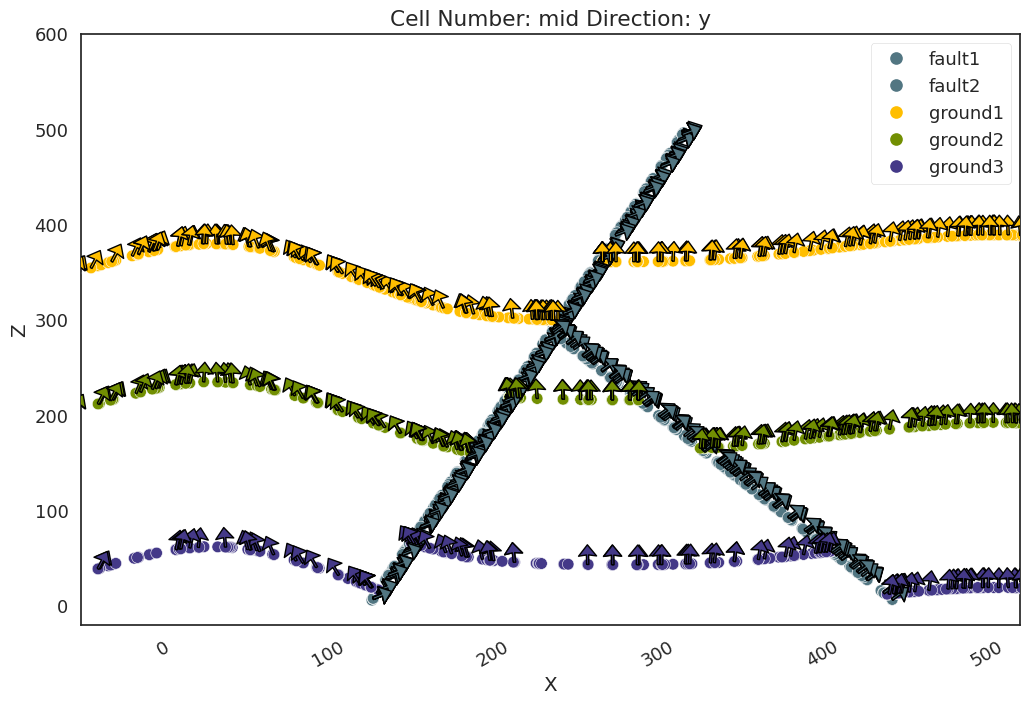

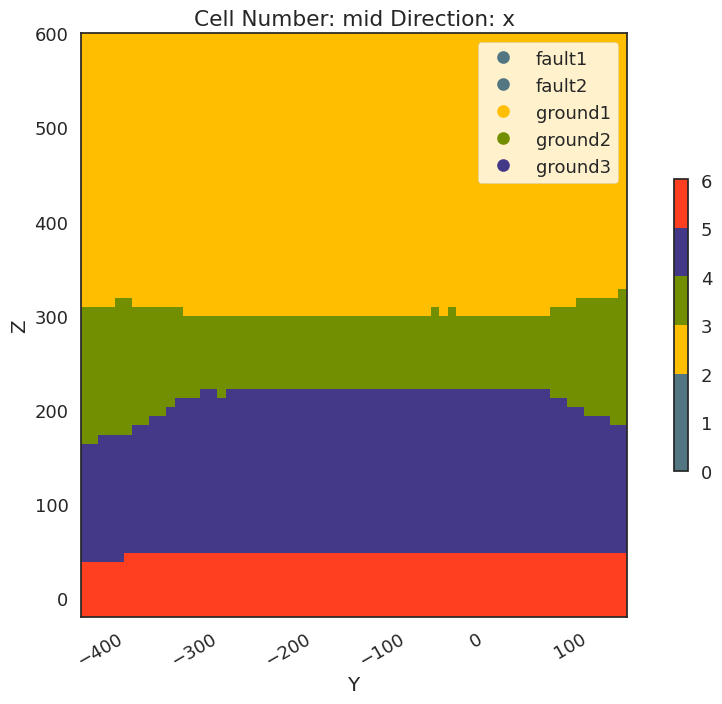

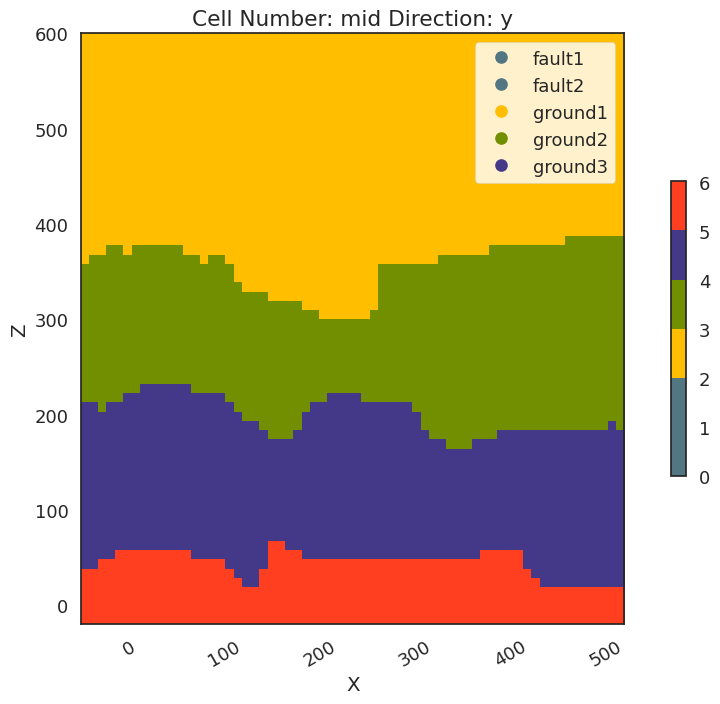

In [9]:
import matplotlib.pyplot as plt

gpv.plot_2d(data, direction=['y'], show_results=False)

# Plot the result of the model in the x and y direction with data and without boundaries
gpv.plot_2d(data, direction=['x'], show_data=False, show_boundaries=False)
gpv.plot_2d(data, direction=['y'], show_data=False, show_boundaries=False)
plt.show()

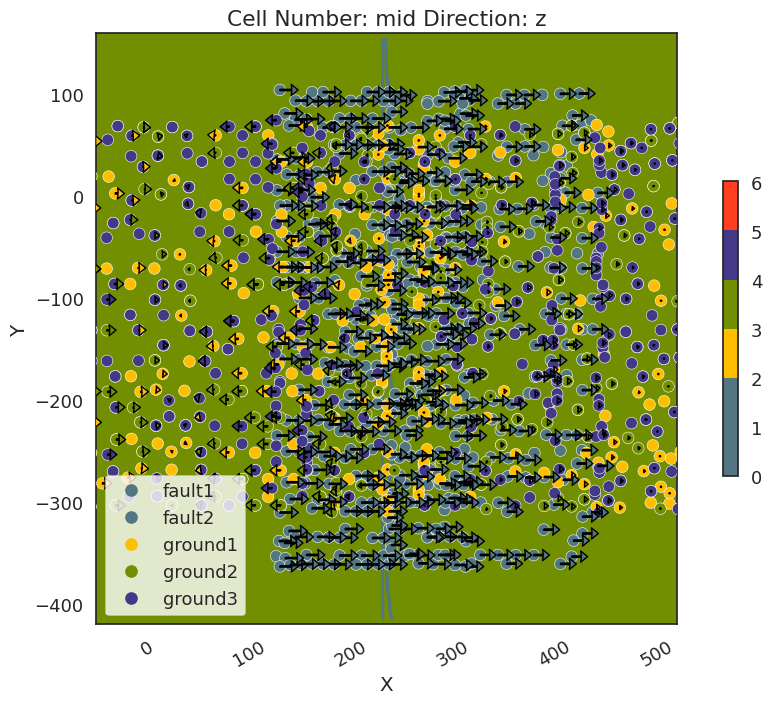

In [10]:
gpv.plot_2d(data, direction=['z'])
plt.show()

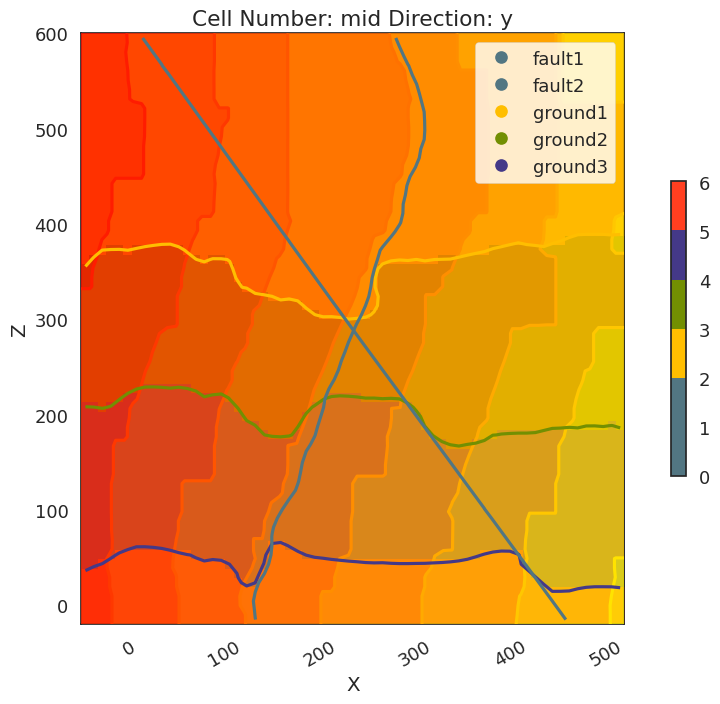

In [11]:
gpv.plot_2d(
    model=data,
    series_n=0,  # This will plot the scalar field used for the fault
    show_data=False,
    show_scalar=True,
    show_lith=True
)
plt.show()

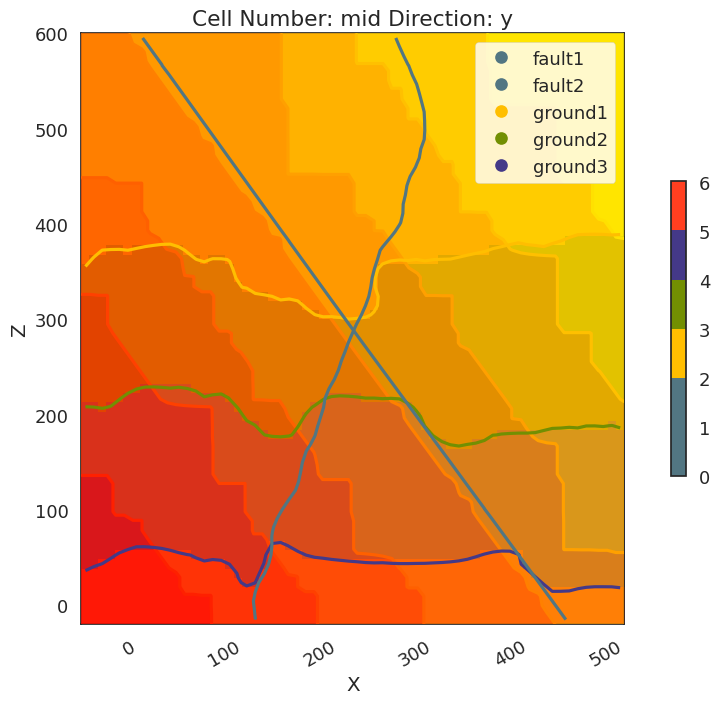

In [12]:
gpv.plot_2d(
    model=data,
    series_n=1,  # This will plot the scalar field used for the fault
    show_data=False,
    show_scalar=True,
    show_lith=True
)
plt.show()